# 05 — Stacking Ensemble
**Ensemble Early Parkinson Detection Using Voice Biomarkers**

This notebook implements a stacking ensemble that combines four diverse base learners under a Logistic Regression meta-learner:

| Level-0 Base Learner | Family | Feature Set | Best Hyperparameters |
|---|---|---|---|
| SVM_RBF | Kernel | SVM-RFE (10) | C=100, gamma=0.001 |
| KNN | Instance-based | RF-RFE | k=15, uniform, euclidean |
| Random Forest | Tree Ensemble | RF-RFE | max_depth=3, 50 trees |
| Logistic L1 | Linear | SVM-RFE (10) | C=1 |

**Architecture:**
- Level-0: Base learners produce cross-validated probability predictions
- Level-1: Regularized Logistic Regression meta-learner combines them
- All evaluation uses subject-wise GroupKFold to prevent data leakage

**Key challenge:** Base learners use *different* feature subsets (SVM-RFE vs RF-RFE), so we implement custom stacking rather than sklearn's StackingClassifier.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.calibration import CalibratedClassifierCV
from imblearn.pipeline import Pipeline as ImbPipeline

from src.data_utils import load_parkinsons, get_X_y_groups, FEATURE_COLS
from src.eval_utils import (
    compute_metrics, results_to_dataframe, plot_confusion_matrix
)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RANDOM_STATE = 42
N_OUTER = 5
N_INNER = 5

df = load_parkinsons()
X, y, groups = get_X_y_groups(df)
print(f'X: {X.shape}, y: {y.shape}, Subjects: {groups.nunique()}')

X: (195, 22), y: (195,), Subjects: 32


## 2. Define Base Learners with Best Hyperparameters

In [2]:
# Feature sets from Notebook 03
SVM_RFE_FEATURES = [
    'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:APQ',
    'spread1', 'D2', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'NHR', 'PPE'
]

rf_rfe_ranking = pd.read_csv('../results/rf_rfe_ranking.csv')
RF_RFE_FEATURES = rf_rfe_ranking[rf_rfe_ranking['times_selected'] >= 3]['feature'].tolist()

print(f'SVM-RFE features ({len(SVM_RFE_FEATURES)}): {SVM_RFE_FEATURES}')
print(f'RF-RFE features ({len(RF_RFE_FEATURES)}): {RF_RFE_FEATURES}')

# Base learners with tuned hyperparameters from Notebook 04
BASE_LEARNERS = {
    'SVM_RBF': {
        'clf': SVC(kernel='rbf', C=100, gamma=0.001, class_weight='balanced',
                   probability=True, random_state=RANDOM_STATE),
        'features': SVM_RFE_FEATURES,
    },
    'KNN': {
        'clf': KNeighborsClassifier(n_neighbors=15, weights='uniform', metric='euclidean'),
        'features': RF_RFE_FEATURES,
    },
    'Random_Forest': {
        'clf': RandomForestClassifier(
            n_estimators=50, max_depth=3, min_samples_split=10,
            min_samples_leaf=2, class_weight='balanced', random_state=RANDOM_STATE
        ),
        'features': RF_RFE_FEATURES,
    },
    'Logistic_L1': {
        'clf': LogisticRegression(
            penalty='l1', C=1, solver='saga', max_iter=5000,
            class_weight='balanced', random_state=RANDOM_STATE
        ),
        'features': SVM_RFE_FEATURES,
    },
}

# Meta-learner: regularized Logistic Regression (kept simple to avoid overfitting)
META_LEARNER = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=5000, random_state=RANDOM_STATE
)

print(f'\nBase learners: {list(BASE_LEARNERS.keys())}')
print(f'Meta-learner: Logistic Regression (L2, C=1.0)')

SVM-RFE features (10): ['MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:APQ', 'spread1', 'D2', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'NHR', 'PPE']
RF-RFE features (8): ['PPE', 'spread1', 'MDVP:APQ', 'MDVP:Fo(Hz)', 'spread2', 'Shimmer:APQ5', 'MDVP:Fhi(Hz)', 'D2']

Base learners: ['SVM_RBF', 'KNN', 'Random_Forest', 'Logistic_L1']
Meta-learner: Logistic Regression (L2, C=1.0)


## 3. Stacking Implementation

The stacking procedure for each outer CV fold:

**Step 1 — Generate level-0 training features (inner CV):**
For each base learner, use inner GroupKFold on the outer training set to produce out-of-fold probability predictions. These become the meta-features for the meta-learner.

**Step 2 — Train meta-learner:**
Fit the meta-learner on the stacked out-of-fold predictions.

**Step 3 — Generate level-0 test features:**
Retrain each base learner on the full outer training set, then predict probabilities on the outer test set.

**Step 4 — Final prediction:**
The meta-learner predicts on the stacked test predictions.

In [3]:
def build_base_pipeline(clf):
    """Wrap a classifier in a StandardScaler pipeline."""
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])


def generate_oof_predictions(base_learners, X, y, groups, n_splits=5):
    """
    Generate out-of-fold (OOF) probability predictions for stacking.
    
    Each base learner is trained on inner CV folds and predicts on the held-out
    portion, producing unbiased meta-features for the meta-learner.
    
    Returns:
        meta_X: np.array of shape (n_samples, n_base_learners) — OOF probabilities
        meta_y: np.array of shape (n_samples,) — true labels (aligned with meta_X)
    """
    n_samples = len(y)
    n_models = len(base_learners)
    meta_X = np.zeros((n_samples, n_models))
    
    inner_cv = GroupKFold(n_splits=n_splits)
    
    for model_idx, (name, config) in enumerate(base_learners.items()):
        features = config['features']
        X_feat = X[features]
        
        for train_idx, val_idx in inner_cv.split(X_feat, y, groups):
            pipe = build_base_pipeline(config['clf'])
            
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                pipe.fit(X_feat.iloc[train_idx], y.iloc[train_idx])
            
            # Predict probability of PD (class 1)
            if hasattr(pipe, 'predict_proba'):
                meta_X[val_idx, model_idx] = pipe.predict_proba(X_feat.iloc[val_idx])[:, 1]
            else:
                meta_X[val_idx, model_idx] = pipe.predict(X_feat.iloc[val_idx])
    
    return meta_X, y.values


def train_base_learners_full(base_learners, X, y):
    """
    Train each base learner on the full training set.
    Returns dict of fitted pipelines.
    """
    fitted = {}
    for name, config in base_learners.items():
        features = config['features']
        pipe = build_base_pipeline(config['clf'])
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            pipe.fit(X[features], y)
        fitted[name] = {'pipeline': pipe, 'features': features}
    return fitted


def predict_base_learners(fitted_models, X):
    """
    Generate probability predictions from all fitted base learners.
    Returns np.array of shape (n_samples, n_models).
    """
    preds = []
    for name, config in fitted_models.items():
        pipe = config['pipeline']
        features = config['features']
        if hasattr(pipe, 'predict_proba'):
            preds.append(pipe.predict_proba(X[features])[:, 1])
        else:
            preds.append(pipe.predict(X[features]))
    return np.column_stack(preds)


print('Stacking helper functions defined.')

Stacking helper functions defined.


## 4. Run Stacking with Subject-wise Outer CV

In [4]:
from sklearn.base import clone

outer_cv = GroupKFold(n_splits=N_OUTER)

# Storage for results
stack_y_trues = []
stack_y_preds = []
stack_y_probs = []
stack_fold_metrics = []
meta_weights_per_fold = []

# Also track individual base learner performance for comparison
base_y_preds = {name: [] for name in BASE_LEARNERS}
base_y_trues = {name: [] for name in BASE_LEARNERS}

print('Running stacking ensemble with subject-wise outer CV...\n')

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups)):
    print(f'--- Outer Fold {fold_idx + 1} ---')
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]
    
    print(f'  Train: {len(y_train)} samples, Test: {len(y_test)} samples')
    print(f'  Test class balance: PD={int(y_test.sum())}, Healthy={int((y_test==0).sum())}')
    
    # Step 1: Generate OOF predictions on training set (inner CV)
    # Need to clone base learners so each fold starts fresh
    fold_base_learners = {
        name: {'clf': clone(config['clf']), 'features': config['features']}
        for name, config in BASE_LEARNERS.items()
    }
    
    meta_X_train, meta_y_train = generate_oof_predictions(
        fold_base_learners, X_train, y_train, groups_train, n_splits=N_INNER
    )
    print(f'  Meta-features (train): {meta_X_train.shape}')
    
    # Step 2: Train meta-learner on OOF predictions
    meta = clone(META_LEARNER)
    meta.fit(meta_X_train, meta_y_train)
    meta_weights_per_fold.append(meta.coef_[0])
    
    # Step 3: Retrain base learners on FULL outer training set
    fold_base_learners_retrain = {
        name: {'clf': clone(config['clf']), 'features': config['features']}
        for name, config in BASE_LEARNERS.items()
    }
    fitted_models = train_base_learners_full(fold_base_learners_retrain, X_train, y_train)
    
    # Step 4: Generate test meta-features and predict
    meta_X_test = predict_base_learners(fitted_models, X_test)
    
    # Stacking predictions
    y_pred_stack = meta.predict(meta_X_test)
    y_prob_stack = meta.predict_proba(meta_X_test)[:, 1]
    
    stack_y_trues.append(y_test.values)
    stack_y_preds.append(y_pred_stack)
    stack_y_probs.append(y_prob_stack)
    stack_fold_metrics.append(compute_metrics(y_test, y_pred_stack, y_prob_stack))
    
    # Track base learner predictions on test set for comparison
    for name, config in fitted_models.items():
        pipe = config['pipeline']
        features = config['features']
        base_pred = pipe.predict(X_test[features])
        base_y_preds[name].append(base_pred)
        base_y_trues[name].append(y_test.values)
    
    fold_m = stack_fold_metrics[-1]
    print(f'  Stacking BA: {fold_m["balanced_accuracy"]:.4f}, '
          f'Sens: {fold_m["sensitivity"]:.4f}, Spec: {fold_m["specificity"]:.4f}')
    print(f'  Meta-learner weights: {dict(zip(BASE_LEARNERS.keys(), meta.coef_[0].round(3)))}')
    print()

print('Stacking ensemble complete!')

Running stacking ensemble with subject-wise outer CV...

--- Outer Fold 1 ---
  Train: 158 samples, Test: 37 samples
  Test class balance: PD=31, Healthy=6
  Meta-features (train): (158, 4)
  Stacking BA: 0.9839, Sens: 0.9677, Spec: 1.0000
  Meta-learner weights: {'SVM_RBF': -0.131, 'KNN': 2.158, 'Random_Forest': 0.808, 'Logistic_L1': 1.967}

--- Outer Fold 2 ---
  Train: 158 samples, Test: 37 samples
  Test class balance: PD=25, Healthy=12
  Meta-features (train): (158, 4)
  Stacking BA: 0.7300, Sens: 0.9600, Spec: 0.5000
  Meta-learner weights: {'SVM_RBF': 0.009, 'KNN': 1.041, 'Random_Forest': -0.396, 'Logistic_L1': 2.324}

--- Outer Fold 3 ---
  Train: 158 samples, Test: 37 samples
  Test class balance: PD=31, Healthy=6
  Meta-features (train): (158, 4)
  Stacking BA: 0.4839, Sens: 0.9677, Spec: 0.0000
  Meta-learner weights: {'SVM_RBF': 0.426, 'KNN': 1.967, 'Random_Forest': 0.738, 'Logistic_L1': 1.517}

--- Outer Fold 4 ---
  Train: 153 samples, Test: 42 samples
  Test class balanc

## 5. Stacking Results

In [7]:
# Aggregate stacking metrics
stack_metrics_df = pd.DataFrame(stack_fold_metrics)
stack_mean = stack_metrics_df.mean()
stack_std = stack_metrics_df.std()

print('=== Stacking Ensemble Results (Subject-wise 5-Fold CV) ===\n')
for metric in ['balanced_accuracy', 'sensitivity', 'specificity', 'accuracy',
               'precision', 'f1', 'mcc', 'auc_roc']:
    print(f'  {metric:>20s}: {stack_mean[metric]:.4f} ± {stack_std[metric]:.4f}')

per_fold_ba = [round(m['balanced_accuracy'], 4) for m in stack_fold_metrics]
print(f'\nPer-fold balanced accuracy: {per_fold_ba}')

=== Stacking Ensemble Results (Subject-wise 5-Fold CV) ===

     balanced_accuracy: 0.6579 ± 0.2134
           sensitivity: 0.9324 ± 0.0572
           specificity: 0.3833 ± 0.3979
              accuracy: 0.7951 ± 0.1267
             precision: 0.8211 ± 0.1124
                    f1: 0.8716 ± 0.0816
                   mcc: 0.3248 ± 0.4301
               auc_roc: 0.8545 ± 0.1806

Per-fold balanced accuracy: [0.9839, 0.73, 0.4839, 0.4583, 0.6333]


## 6. Meta-Learner Weight Analysis

The meta-learner coefficients reveal how much it relies on each base learner.

Meta-learner coefficients per fold:

        SVM_RBF     KNN  Random_Forest  Logistic_L1
Fold 1  -0.1308  2.1580         0.8076       1.9675
Fold 2   0.0089  1.0406        -0.3959       2.3240
Fold 3   0.4264  1.9670         0.7378       1.5171
Fold 4   1.4197 -0.8439        -0.4964       2.4113
Fold 5  -0.6825  2.6693         1.6091       0.9082
Mean     0.2083  1.3982         0.4524       1.8256
Std      0.7848  1.3849         0.8896       0.6222


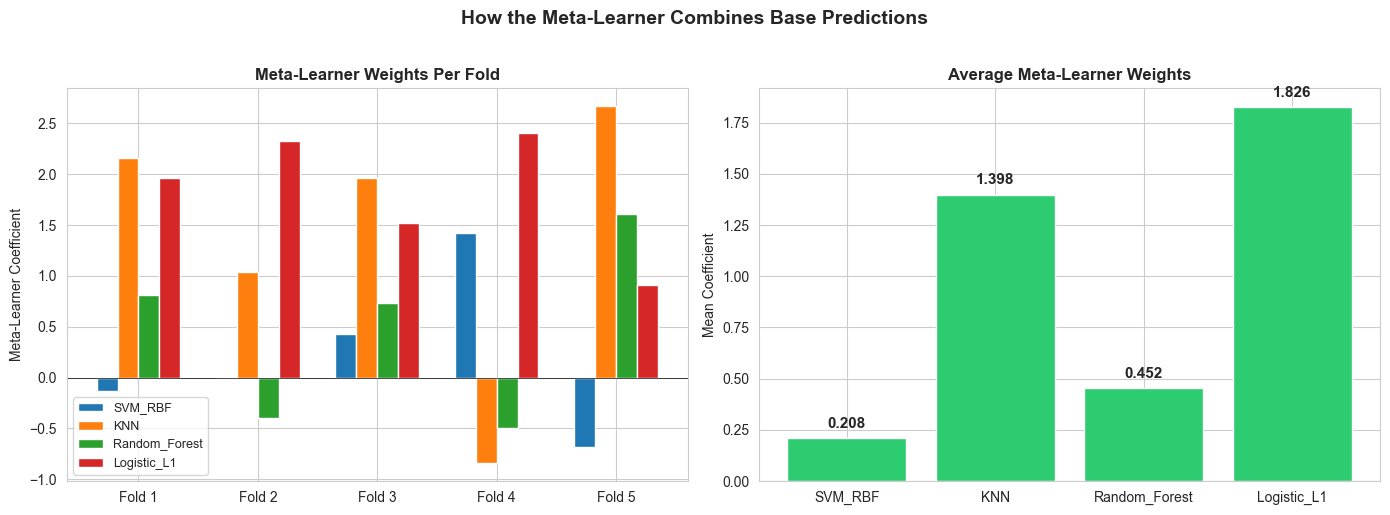

In [8]:
weights_df = pd.DataFrame(
    meta_weights_per_fold,
    columns=list(BASE_LEARNERS.keys()),
    index=[f'Fold {i+1}' for i in range(N_OUTER)]
)
weights_df.loc['Mean'] = weights_df.mean()
weights_df.loc['Std'] = weights_df.iloc[:N_OUTER].std()

print('Meta-learner coefficients per fold:\n')
print(weights_df.round(4).to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-fold weights
weights_df.iloc[:N_OUTER].plot(kind='bar', ax=axes[0], width=0.7)
axes[0].set_ylabel('Meta-Learner Coefficient')
axes[0].set_title('Meta-Learner Weights Per Fold', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].legend(fontsize=9)

# Mean weights
mean_weights = weights_df.loc['Mean']
colors = ['#e74c3c' if w < 0 else '#2ecc71' for w in mean_weights]
axes[1].bar(mean_weights.index, mean_weights.values, color=colors, edgecolor='white')
axes[1].set_ylabel('Mean Coefficient')
axes[1].set_title('Average Meta-Learner Weights', fontsize=12, fontweight='bold')
axes[1].axhline(y=0, color='black', linewidth=0.5)

for i, (name, val) in enumerate(mean_weights.items()):
    axes[1].text(i, val + 0.05 * np.sign(val), f'{val:.3f}',
                 ha='center', fontsize=11, fontweight='bold')

plt.suptitle('How the Meta-Learner Combines Base Predictions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/meta_learner_weights.png', bbox_inches='tight')
plt.show()

## 7. Stacking vs Individual Models Comparison

In [9]:
# Compute metrics for individual base learners (from this same outer CV run)
comparison = {}

# Stacking
all_yt_stack = np.concatenate(stack_y_trues)
all_yp_stack = np.concatenate(stack_y_preds)
all_yprob_stack = np.concatenate(stack_y_probs)
comparison['Stacking Ensemble'] = compute_metrics(all_yt_stack, all_yp_stack, all_yprob_stack)

# Individual base learners (from the same outer folds)
for name in BASE_LEARNERS:
    all_yt = np.concatenate(base_y_trues[name])
    all_yp = np.concatenate(base_y_preds[name])
    comparison[name] = compute_metrics(all_yt, all_yp)

comp_df = results_to_dataframe(comparison)
print('--- Stacking vs Individual Base Learners (Same Outer CV Folds) ---\n')
print(comp_df.to_string())

--- Stacking vs Individual Base Learners (Same Outer CV Folds) ---

                   accuracy  balanced_accuracy  sensitivity  specificity  precision      f1     mcc  auc_roc
Model                                                                                                       
Stacking Ensemble    0.7897             0.6431       0.9320       0.3542     0.8155  0.8698  0.3569   0.8424
SVM_RBF              0.7436             0.7317       0.7551       0.7083     0.8880  0.8162  0.4162      NaN
KNN                  0.8256             0.7160       0.9320       0.5000     0.8509  0.8896  0.4904      NaN
Random_Forest        0.7538             0.6614       0.8435       0.4792     0.8322  0.8378  0.3274      NaN
Logistic_L1          0.7795             0.7625       0.7959       0.7292     0.9000  0.8448  0.4798      NaN


In [10]:
# Also compare against best individual tuned model from Notebook 04
nb04_results = pd.read_csv('../results/tuned_results.csv', index_col=0)

full_comparison = {}
full_comparison['Stacking (this notebook)'] = stack_mean.to_dict()

for model_name in nb04_results.index:
    full_comparison[f'{model_name} (NB04 tuned)'] = nb04_results.loc[model_name].to_dict()

full_comp_df = results_to_dataframe(full_comparison)
print('--- Full Comparison: Stacking vs All Tuned Models (NB04) ---\n')
print(full_comp_df.to_string())

--- Full Comparison: Stacking vs All Tuned Models (NB04) ---

                            accuracy  balanced_accuracy  sensitivity  specificity  precision      f1     mcc  auc_roc
Model                                                                                                                
Stacking (this notebook)      0.7951             0.6579       0.9324       0.3833     0.8211  0.8716  0.3248   0.8545
SVM_RBF (NB04 tuned)          0.7112             0.6706       0.7579       0.5833     0.8447  0.7925  0.3118   0.8123
SVM_Linear (NB04 tuned)       0.7512             0.7193       0.7719       0.6667     0.8824  0.8197  0.3920   0.8403
KNN (NB04 tuned)              0.8211             0.7175       0.9184       0.5167     0.8595  0.8850  0.4267   0.9127
Random_Forest (NB04 tuned)    0.7789             0.6776       0.8720       0.4833     0.8440  0.8546  0.3311   0.8862
Logistic_L1 (NB04 tuned)      0.7601             0.7368       0.7737       0.7000     0.8991  0.8236  0.4300   0

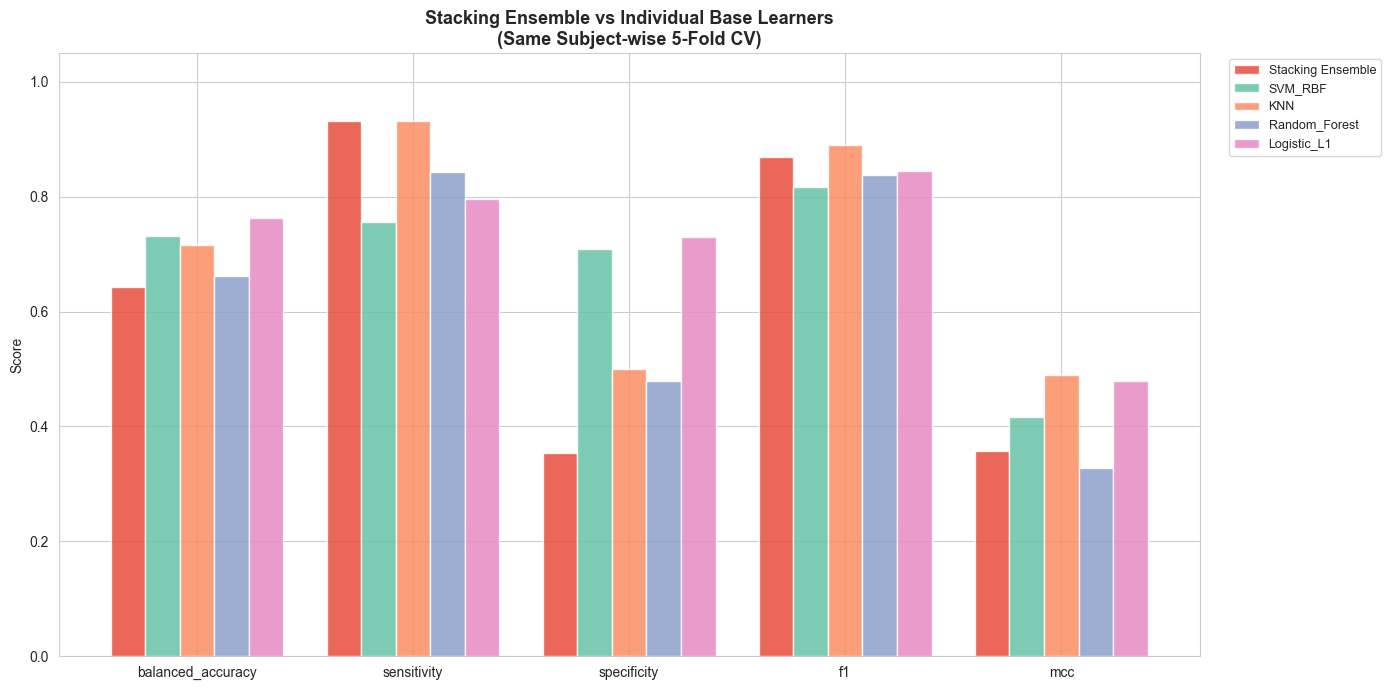

In [11]:
# Visualize comparison
metrics_to_plot = ['balanced_accuracy', 'sensitivity', 'specificity', 'f1', 'mcc']
models_to_plot = ['Stacking Ensemble'] + list(BASE_LEARNERS.keys())

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(metrics_to_plot))
n_models = len(models_to_plot)
width = 0.8 / n_models

colors = ['#e74c3c'] + list(sns.color_palette('Set2', n_models - 1))

for i, model_name in enumerate(models_to_plot):
    vals = [comp_df.loc[model_name, m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=model_name, color=colors[i],
           alpha=0.85, edgecolor='white')

ax.set_ylabel('Score')
ax.set_title('Stacking Ensemble vs Individual Base Learners\n(Same Subject-wise 5-Fold CV)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(metrics_to_plot)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../figures/stacking_vs_individual.png', bbox_inches='tight')
plt.show()

## 8. Confusion Matrices

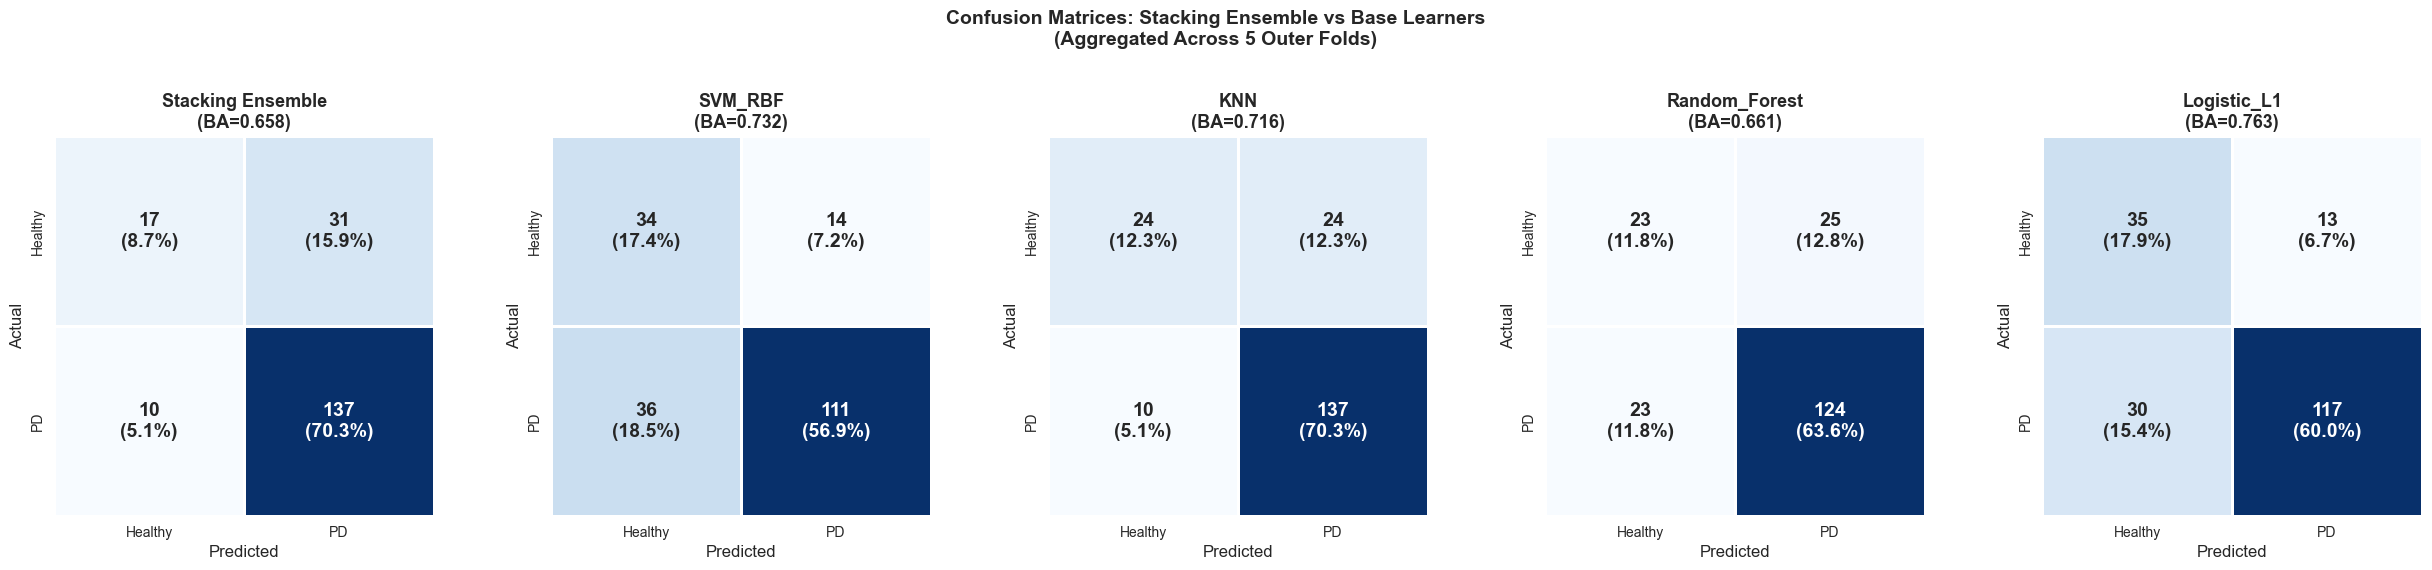

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

# Stacking first
plot_confusion_matrix(
    all_yt_stack, all_yp_stack,
    title=f'Stacking Ensemble\n(BA={stack_mean["balanced_accuracy"]:.3f})',
    ax=axes[0]
)

# Then individual base learners
for ax_idx, name in enumerate(BASE_LEARNERS.keys(), 1):
    all_yt = np.concatenate(base_y_trues[name])
    all_yp = np.concatenate(base_y_preds[name])
    ba = comparison[name]['balanced_accuracy']
    plot_confusion_matrix(all_yt, all_yp, title=f'{name}\n(BA={ba:.3f})', ax=axes[ax_idx])

plt.suptitle('Confusion Matrices: Stacking Ensemble vs Base Learners\n(Aggregated Across 5 Outer Folds)',
             fontsize=14, fontweight='bold', y=1.08)
plt.tight_layout()
plt.savefig('../figures/stacking_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 9. Ablation Study — Does Each Base Learner Contribute?

Remove one base learner at a time and re-run stacking to measure each model's marginal contribution.

In [13]:
ablation_results = {}

for remove_name in BASE_LEARNERS.keys():
    # Create subset of base learners
    subset = {k: v for k, v in BASE_LEARNERS.items() if k != remove_name}
    
    outer_cv = GroupKFold(n_splits=N_OUTER)
    abl_y_trues, abl_y_preds = [], []
    
    for train_idx, test_idx in outer_cv.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        groups_train = groups.iloc[train_idx]
        
        # Clone for this fold
        fold_subset = {
            name: {'clf': clone(config['clf']), 'features': config['features']}
            for name, config in subset.items()
        }
        
        # OOF predictions
        meta_X_train, meta_y_train = generate_oof_predictions(
            fold_subset, X_train, y_train, groups_train, n_splits=N_INNER
        )
        
        # Train meta-learner
        meta = clone(META_LEARNER)
        meta.fit(meta_X_train, meta_y_train)
        
        # Retrain base learners on full training set
        fold_subset_retrain = {
            name: {'clf': clone(config['clf']), 'features': config['features']}
            for name, config in subset.items()
        }
        fitted = train_base_learners_full(fold_subset_retrain, X_train, y_train)
        meta_X_test = predict_base_learners(fitted, X_test)
        
        abl_y_trues.append(y_test.values)
        abl_y_preds.append(meta.predict(meta_X_test))
    
    all_yt = np.concatenate(abl_y_trues)
    all_yp = np.concatenate(abl_y_preds)
    ablation_results[f'Without {remove_name}'] = compute_metrics(all_yt, all_yp)

# Add full stacking for comparison
ablation_results['Full Stacking (4 models)'] = compute_metrics(all_yt_stack, all_yp_stack, all_yprob_stack)

ablation_df = results_to_dataframe(ablation_results)
print('--- Ablation Study: Impact of Removing Each Base Learner ---\n')
print(ablation_df.to_string())

--- Ablation Study: Impact of Removing Each Base Learner ---

                          accuracy  balanced_accuracy  sensitivity  specificity  precision      f1     mcc  auc_roc
Model                                                                                                              
Without SVM_RBF             0.8000             0.6639       0.9320       0.3958     0.8253  0.8754  0.3969      NaN
Without KNN                 0.7795             0.6363       0.9184       0.3542     0.8133  0.8626  0.3299      NaN
Without Random_Forest       0.8051             0.6673       0.9388       0.3958     0.8263  0.8790  0.4110      NaN
Without Logistic_L1         0.8051             0.6533       0.9524       0.3542     0.8187  0.8805  0.4020      NaN
Full Stacking (4 models)    0.7897             0.6431       0.9320       0.3542     0.8155  0.8698  0.3569   0.8424


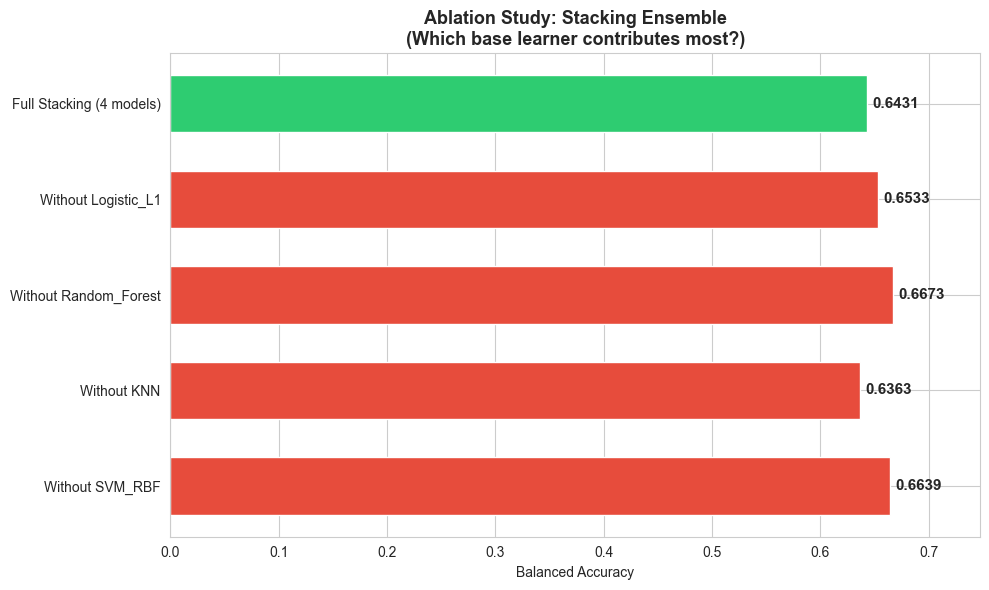


Contribution of each base learner (drop in BA when removed):
  Removing SVM_RBF: BA goes 0.6431 → 0.6639 (-0.0208) — HELPS ensemble
  Removing KNN: BA goes 0.6431 → 0.6363 (+0.0068) — HURTS ensemble
  Removing Random_Forest: BA goes 0.6431 → 0.6673 (-0.0242) — HELPS ensemble
  Removing Logistic_L1: BA goes 0.6431 → 0.6533 (-0.0102) — HELPS ensemble


In [14]:
# Visualize ablation
fig, ax = plt.subplots(figsize=(10, 6))

abl_models = list(ablation_df.index)
ba_vals = ablation_df['balanced_accuracy'].values
colors = ['#2ecc71' if 'Full' in m else '#e74c3c' for m in abl_models]

bars = ax.barh(abl_models, ba_vals, color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Balanced Accuracy')
ax.set_title('Ablation Study: Stacking Ensemble\n(Which base learner contributes most?)',
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, ba_vals):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, max(ba_vals) + 0.08)
plt.tight_layout()
plt.savefig('../figures/stacking_ablation.png', bbox_inches='tight')
plt.show()

# Identify most/least important
full_ba = ablation_results['Full Stacking (4 models)']['balanced_accuracy']
print('\nContribution of each base learner (drop in BA when removed):')
for name in BASE_LEARNERS:
    removed_ba = ablation_results[f'Without {name}']['balanced_accuracy']
    drop = full_ba - removed_ba
    direction = 'HURTS' if drop > 0 else 'HELPS' if drop < 0 else 'NEUTRAL'
    print(f'  Removing {name}: BA goes {full_ba:.4f} → {removed_ba:.4f} ({drop:+.4f}) — {direction} ensemble')

## 10. Save Results

In [ ]:
# Save stacking results
stack_results_dict = {
    'metric': list(stack_mean.index),
    'mean': list(stack_mean.values),
    'std': list(stack_std.values)
}
pd.DataFrame(stack_results_dict).to_csv('../results/stacking_results.csv', index=False)

# Save comparison
comp_df.to_csv('../results/stacking_vs_individual.csv')
ablation_df.to_csv('../results/stacking_ablation.csv')
weights_df.to_csv('../results/meta_learner_weights.csv')

print('Saved to results/:')
print('  stacking_results.csv')
print('  stacking_vs_individual.csv')
print('  stacking_ablation.csv')
print('  meta_learner_weights.csv')

## 11. Key Takeaways

Fill in after running:

1. **Stacking performance**: Balanced accuracy = ___ ± ___, Sensitivity = ___, Specificity = ___
2. **Does stacking beat individual models?** Compare against best individual (Logistic_L2 at 0.7558)
3. **Meta-learner weights**: Which base learners does the meta-learner rely on most? Are weights stable across folds?
4. **Ablation study**: Which base learner contributes most to the ensemble? Which is least useful?
5. **Clinical interpretation**: How would this perform as a screening tool? (Sensitivity vs specificity tradeoff)

**Next step**: Notebook 06 — Final Results Compilation